In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

# Create Folder to Save Images
os.makedirs("output_images", exist_ok=True)

In [2]:
data = load_iris()

X = data.data
y = data.target

df = pd.DataFrame(
    X,
    columns=data.feature_names
)

df["Target"] = y

In [3]:
print("Dataset Shape")
print(df.shape)

Dataset Shape
(150, 5)


In [4]:
print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [5]:
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      Target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [6]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64


In [7]:
print("Duplicate Rows")

print(df.duplicated().sum())

Duplicate Rows
1


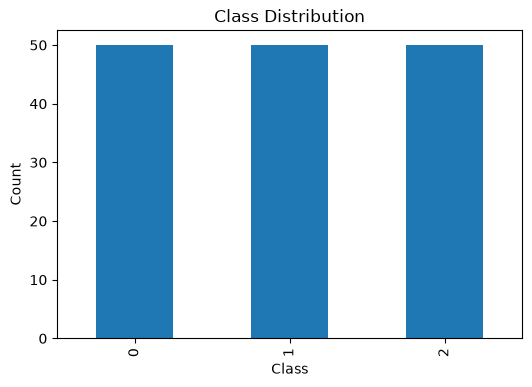

In [8]:
plt.figure(figsize=(6,4))

df["Target"].value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.savefig(
    "output_images/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

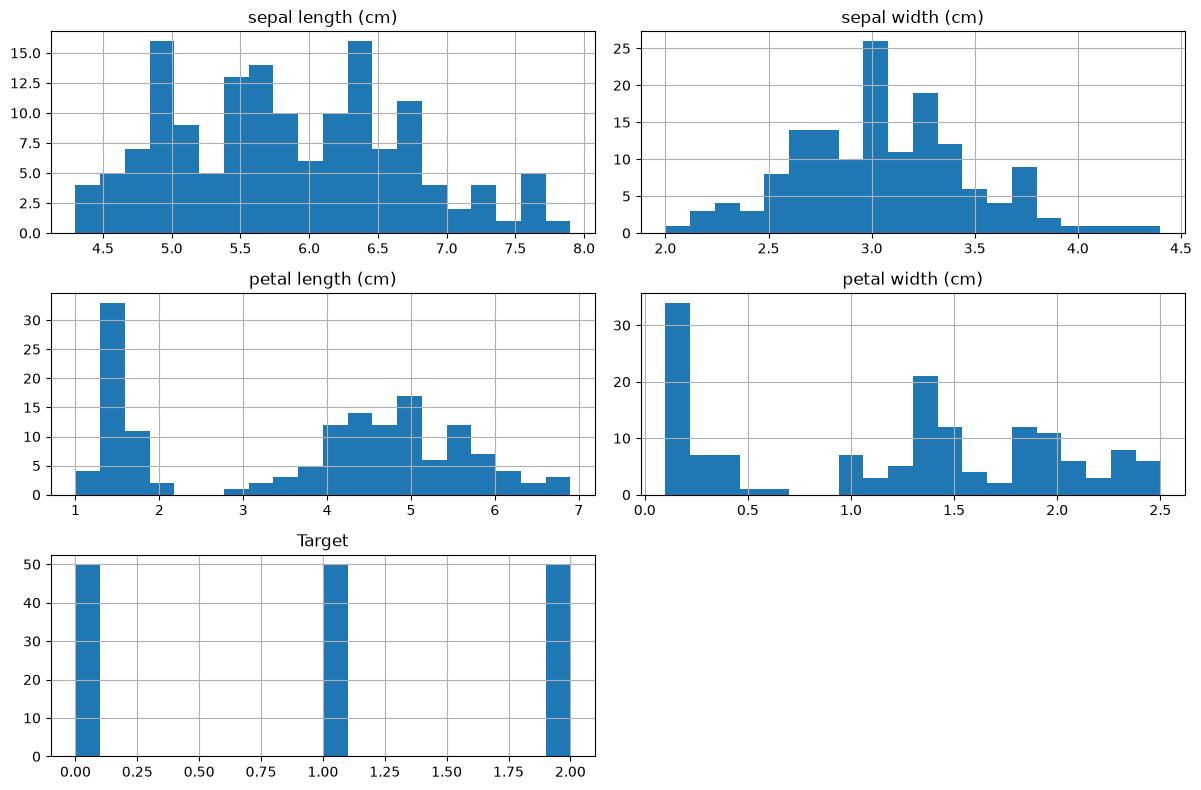

In [9]:
df.hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()

plt.savefig(
    "output_images/histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

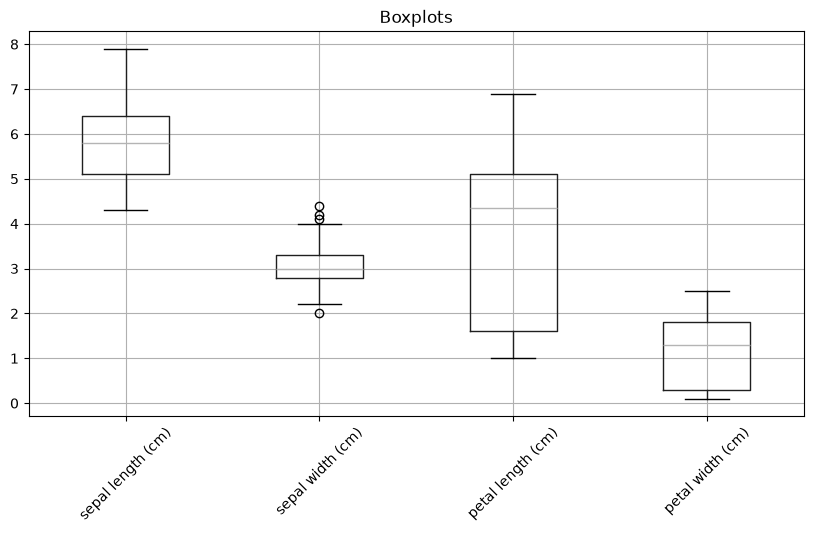

In [10]:
plt.figure(figsize=(10,5))

df.drop(
    "Target",
    axis=1
).boxplot()

plt.xticks(rotation=45)

plt.title("Boxplots")

plt.savefig(
    "output_images/boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

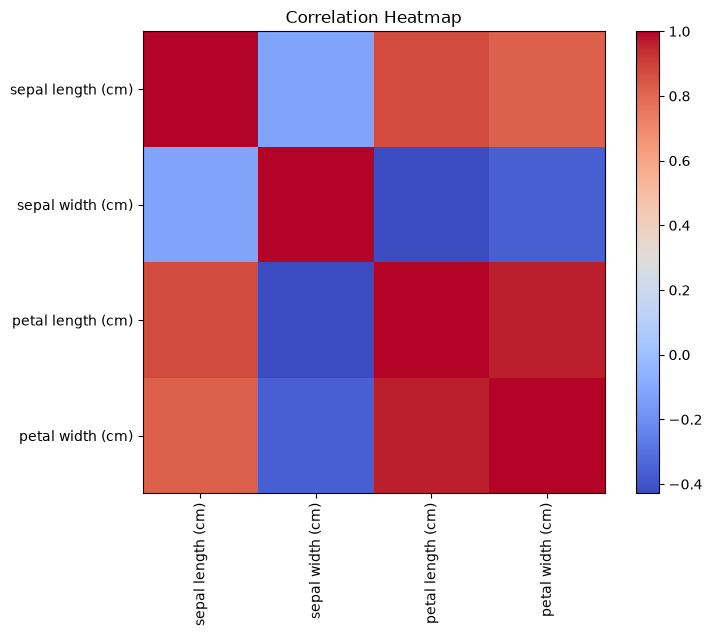

In [13]:
corr = df.drop(
    "Target",
    axis=1
).corr()

plt.figure(figsize=(8,6))

plt.imshow(
    corr,
    cmap="coolwarm"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Heatmap")

plt.savefig(
    "output_images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

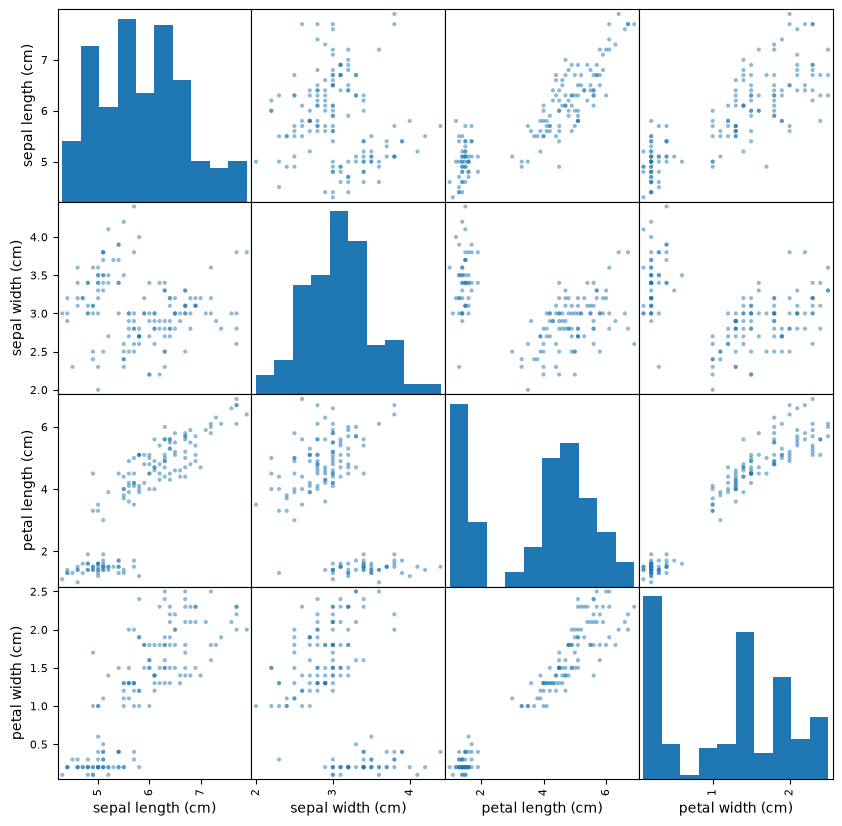

In [14]:
from pandas.plotting import scatter_matrix

scatter_matrix(
    df.iloc[:,0:4],
    figsize=(10,10),
    diagonal="hist"
)

plt.savefig(
    "output_images/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

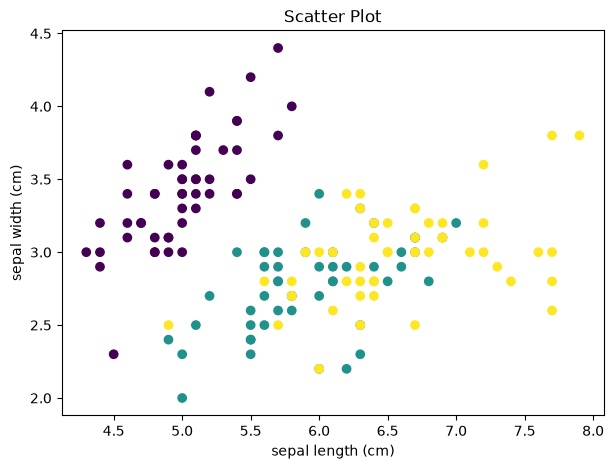

In [15]:
plt.figure(figsize=(7,5))

plt.scatter(
    df.iloc[:,0],
    df.iloc[:,1],
    c=df["Target"]
)

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])

plt.title("Scatter Plot")

plt.savefig(
    "output_images/scatter_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

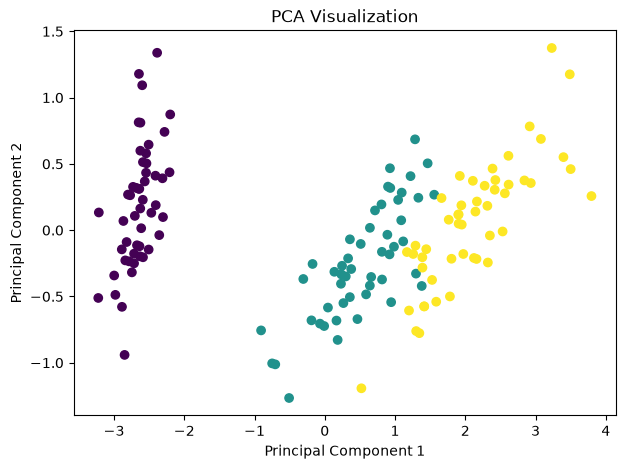

In [16]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Visualization")

plt.savefig(
    "output_images/pca_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:

# Remove duplicate rows (if any)
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates")
print(df.shape)

Dataset Shape After Removing Duplicates
(149, 5)


In [19]:
# ==========================================
# Feature & Target
# ==========================================

X = df.drop(
    "Target",
    axis=1
)

y = df["Target"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(119, 4)
(30, 4)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

# basic model -svm - rbf

In [24]:
from sklearn.svm import SVC

model = SVC(

    kernel="rbf",

    random_state=42
)

model.fit(

    X_train,

    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [25]:
y_pred = model.predict(

    X_test
)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


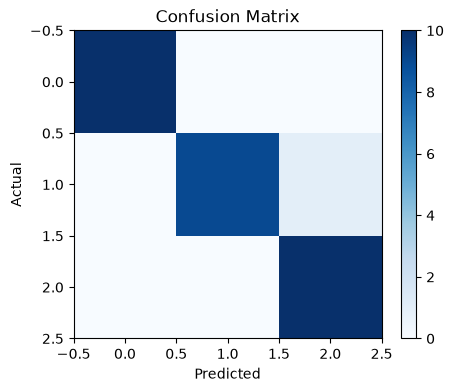

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    y_test,

    y_pred
)

print(cm)

plt.figure(figsize=(5,4))

plt.imshow(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "output_images/confusion_matrix_default.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
from sklearn.metrics import accuracy_score ,precision_score,recall_score

accuracy = accuracy_score(

    y_test,

    y_pred
)
precision = precision_score(

    y_test,

    y_pred,

    average="weighted"
)

recall = recall_score(

    y_test,

    y_pred,

    average="weighted"
)


print("F1 Score")


print("Recall")

print(recall)

print("Precision")

print(precision)

print("Accuracy")

print(accuracy)

F1 Score
Recall
0.9666666666666667
Precision
0.9696969696969696
Accuracy
0.9666666666666667


In [33]:
from sklearn.metrics import f1_score

f1 = f1_score(

    y_test,

    y_pred,

    average="weighted"
)

print("F1 Score")

print(f1)

F1 Score
0.9665831244778613


In [34]:
from sklearn.metrics import classification_report

print(

    classification_report(

        y_test,

        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [35]:
result = {

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1
    ]
}

result_df = pd.DataFrame(result)

print(result_df)

      Metric     Value
0   Accuracy  0.966667
1  Precision  0.969697
2     Recall  0.966667
3   F1 Score  0.966583


# Part 3 : GridSearchCV + Best Model + Final Evaluation

Best Parameters
{'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}

Best Cross Validation Score
0.9666666666666668

Best Model
SVC(C=0.1, degree=2, kernel='linear', random_state=42)

Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


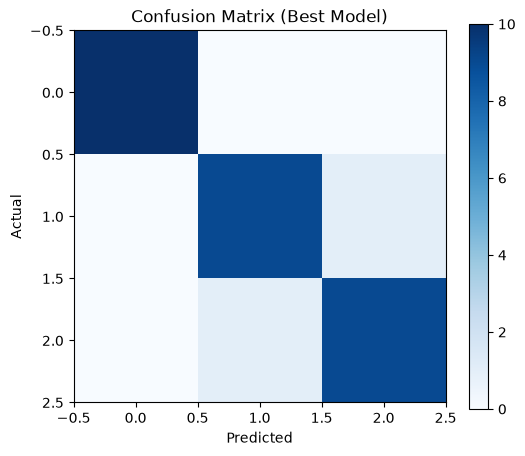


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Final Performance
Accuracy : 0.9333333333333333
Precision : 0.9333333333333333
Recall : 0.9333333333333333
F1 Score : 0.9333333333333333

Comparison
      Metric  Default SVM  GridSearchCV SVM
0   Accuracy     0.966667          0.933333
1  Precision     0.969697          0.933333
2     Recall     0.966667          0.933333
3   F1 Score     0.966583          0.933333


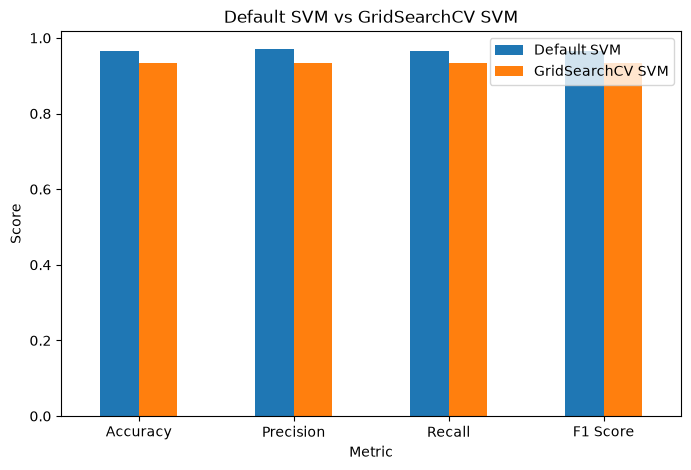


Model Saved Successfully
best_svm_model.pkl
scaler.pkl

FINAL CONCLUSION


✓ Dataset Successfully Loaded

✓ Dataset Analyzed using EDA

✓ Data Cleaning Completed

✓ Feature Scaling Applied

✓ Default SVM Trained

✓ Performance Evaluated

✓ Hyperparameter Tuning Completed using GridSearchCV

✓ Best Parameters Selected

✓ Best SVM Model Obtained

✓ Final Performance Evaluated

✓ Default Model Compared with Tuned Model

✓ Best Model Saved Successfully

Machine Learning Pipeline Completed Successfully.




In [36]:


import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)



param_grid = {

    "kernel": ["linear", "rbf", "poly"],

    "C": [0.1, 1, 10],

    "gamma": ["scale", "auto"],

    "degree": [2, 3, 4]

}



grid = GridSearchCV(

    estimator=model,

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)



grid.fit(

    X_train,

    y_train
)



print("="*60)
print("Best Parameters")
print("="*60)

print(grid.best_params_)

print()

print("="*60)
print("Best Cross Validation Score")
print("="*60)

print(grid.best_score_)


best_model = grid.best_estimator_

print()

print("="*60)
print("Best Model")
print("="*60)

print(best_model)



y_pred_best = best_model.predict(

    X_test
)



accuracy_best = accuracy_score(

    y_test,

    y_pred_best
)

precision_best = precision_score(

    y_test,

    y_pred_best,

    average="weighted"
)

recall_best = recall_score(

    y_test,

    y_pred_best,

    average="weighted"
)

f1_best = f1_score(

    y_test,

    y_pred_best,

    average="weighted"
)



cm = confusion_matrix(

    y_test,

    y_pred_best
)

print()

print("="*60)
print("Confusion Matrix")
print("="*60)

print(cm)

plt.figure(figsize=(6,5))

plt.imshow(

    cm,

    cmap="Blues"

)

plt.colorbar()

plt.title("Confusion Matrix (Best Model)")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(

    "output_images/confusion_matrix_best.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()


print()

print("="*60)
print("Classification Report")
print("="*60)

print(

    classification_report(

        y_test,

        y_pred_best
    )
)

# ==========================================================
# Final Metrics
# ==========================================================

print()

print("="*60)
print("Final Performance")
print("="*60)

print("Accuracy :", accuracy_best)

print("Precision :", precision_best)

print("Recall :", recall_best)

print("F1 Score :", f1_best)

# ==========================================================
# Compare Default vs Tuned Model
# ==========================================================

comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Default SVM":[

        accuracy,

        precision,

        recall,

        f1

    ],

    "GridSearchCV SVM":[

        accuracy_best,

        precision_best,

        recall_best,

        f1_best

    ]

})

print()

print("="*60)
print("Comparison")
print("="*60)

print(comparison)

# ==========================================================
# Comparison Bar Chart
# ==========================================================

comparison.set_index(

    "Metric"

).plot(

    kind="bar",

    figsize=(8,5)

)

plt.title("Default SVM vs GridSearchCV SVM")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.savefig(

    "output_images/model_comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# ==========================================================
# Save Best Model
# ==========================================================

joblib.dump(

    best_model,

    "best_svm_model.pkl"

)

joblib.dump(

    scaler,

    "scaler.pkl"

)

print()

print("="*60)
print("Model Saved Successfully")
print("="*60)

print("best_svm_model.pkl")

print("scaler.pkl")

# ==========================================================
# Final Conclusion
# ==========================================================

print()

print("="*70)
print("FINAL CONCLUSION")
print("="*70)

print("""

✓ Dataset Successfully Loaded

✓ Dataset Analyzed using EDA

✓ Data Cleaning Completed

✓ Feature Scaling Applied

✓ Default SVM Trained

✓ Performance Evaluated

✓ Hyperparameter Tuning Completed using GridSearchCV

✓ Best Parameters Selected

✓ Best SVM Model Obtained

✓ Final Performance Evaluated

✓ Default Model Compared with Tuned Model

✓ Best Model Saved Successfully

Machine Learning Pipeline Completed Successfully.

""")